# Feasibility Probe — MountainCar Safe-RL

**Question:** is there any trajectory that reaches the goal **while** keeping the
total cost (speed penalty) below the limit of 15?

This is **not training**. We copy the MountainCar physics (exactly the gymnasium
constants), then run a hand-written controller to measure the cost of trajectories
that successfully solve. The goal is to answer "wall or not?" cheaply.

In [20]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Dynamics constants & cost rule

The dynamics are identical to `MountainCar-v0`. The cost rule is taken from
`src/envs.py` (`ConstrainedMountainCar`): at each step, if `|v| > 0.04`, the cost
is `(|v| - 0.04) * 100`; otherwise it is 0.

In [21]:
# MountainCar-v0 dynamics (identical to gymnasium)
FORCE   = 0.001
GRAVITY = 0.0025
MAX_SPEED = 0.07
MIN_POS, MAX_POS = -1.2, 0.6
GOAL = 0.5
MAX_EP_LEN = 200

# Cost rule from ConstrainedMountainCar
SPEED_THRESH = 0.04
COST_LIMIT   = 15.0

## 2. One-step physics, cost, and a single episode

In [22]:
def step(pos, vel, action):
    # action: 0 = push left, 1 = no push, 2 = push right
    vel += (action - 1) * FORCE + np.cos(3 * pos) * (-GRAVITY)
    vel = np.clip(vel, -MAX_SPEED, MAX_SPEED)
    pos += vel
    if pos < MIN_POS:
        pos = MIN_POS
        if vel < 0:
            vel = 0.0
    return pos, vel

def step_cost(vel):
    # cost definition: (|v| - 0.04) * 100, only when speeding
    v = abs(vel)
    return (v - SPEED_THRESH) * 100.0 if v > SPEED_THRESH else 0.0

def run_episode(policy, start_pos, max_len=MAX_EP_LEN):
    pos, vel = start_pos, 0.0
    total_cost = 0.0
    for t in range(max_len):
        a = policy(pos, vel)
        pos, vel = step(pos, vel, a)
        total_cost += step_cost(vel)          # accumulate per-step cost
        if pos >= GOAL:                        # reached goal -> done
            return dict(solved=True, steps=t + 1, cost=total_cost)
    return dict(solved=False, steps=max_len, cost=total_cost)

## 3. Two controllers

- `pump` — plain speeding: keep pumping momentum, no braking.
- `pump_capped(cap)` — "push but don't speed": pump, but as soon as the speed
  reaches `cap`, release the throttle. A smaller cap = cheaper cost but slower.

In [23]:
def pump(pos, vel):
    return 2 if vel >= 0 else 0

def pump_capped(cap):
    def pol(pos, vel):
        if abs(vel) >= cap:
            return 1                            # coasting
        return 2 if vel >= 0 else 0
    return pol

## 4. Run the sweep over 200 random starts

### Why these cap values?

The cap list is **not arbitrary** — both endpoints are fixed by the task physics,
and the spacing is deliberate:

- **Upper bound = 0.070** is `MAX_SPEED`. The speed is clipped to ±0.07, so capping
  above 0.07 is pointless (it would never be reached). This is the "as aggressive
  as possible" end.
- **Lower bound = 0.040** is `SPEED_THRESH`, the cost threshold. Cost only appears
  when `|v| > 0.04`, so any cap ≤ 0.04 yields **zero cost by construction** — but
  also makes the car too slow to solve. So 0.04 is the natural floor: the "as
  thrifty as still sensible" end. Testing below it is uninteresting.
- **Why the points get denser toward 0.040** (steps of 0.001–0.002 near the bottom
  vs. 0.005–0.010 at the top): the region near the 0.04 threshold is the **critical
  zone where feasibility is decided**. That is where the mean cost crosses the
  limit of 15 (see the table: cap 0.050 → cost 16.9 is still above, cap 0.045 →
  13.8 is already below). Because the "pass / fail" transition happens in this
  narrow band, it is sampled densely for resolution. Higher up (large caps), cost
  is far from the limit and clearly fails, so coarse sampling is enough to see the
  trend.

In short: the range `[0.040, 0.070]` = `[cost threshold, max speed]`, with points
concentrated near the threshold because that is exactly where the feasible vs.
infeasible boundary lies.

In [24]:
rng = np.random.default_rng(0)
starts = rng.uniform(-0.6, -0.4, size=200)     # same as MountainCar reset

def evaluate(policy):
    res = [run_episode(policy, s) for s in starts]
    solved = [r for r in res if r['solved']]
    costs  = np.array([r['cost']  for r in solved]) if solved else np.array([])
    steps  = np.array([r['steps'] for r in solved]) if solved else np.array([])
    return dict(rate=len(solved)/len(res), costs=costs, steps=steps)

# Range = [below cost threshold to max speed]; denser near the 0.04 boundary
caps = [0.070, 0.060, 0.055, 0.050, 0.045, 0.043, 0.042, 0.041, 0.040,
        0.035, 0.030, 0.025, 0.020]
rows = []
for cap in caps:
    r = evaluate(pump_capped(cap))
    rows.append(dict(cap=cap,
                     rate=r['rate'],
                     cmin=r['costs'].min() if len(r['costs']) else float('nan'),
                     cmean=r['costs'].mean() if len(r['costs']) else float('nan'),
                     cmax=r['costs'].max() if len(r['costs']) else float('nan'),
                     steps=r['steps'].mean() if len(r['steps']) else float('nan'),
                     safe_frac=(r['costs'] <= COST_LIMIT).mean() if len(r['costs']) else float('nan')))

print(f"{'cap':>6} {'solve':>6} {'cost min':>9} {'cost MEAN':>10} {'cost max':>9} {'steps':>6} {'<=15':>6}")
for x in rows:
    print(f"{x['cap']:6.3f} {x['rate']:6.0%} {x['cmin']:9.1f} {x['cmean']:10.1f} {x['cmax']:9.1f} {x['steps']:6.0f} {x['safe_frac']:6.0%}")

fast = evaluate(pump)
print(f"\nplain speeding: solve={fast['rate']:.0%}, cost mean={fast['costs'].mean():.1f}")

   cap  solve  cost min  cost MEAN  cost max  steps   <=15
 0.070   100%      10.8       29.2      41.3    120    18%
 0.060   100%      10.8       26.9      36.2    120    18%
 0.055   100%      10.8       21.1      26.8    121    18%
 0.050   100%      10.1       16.9      22.4    124    40%
 0.045   100%       5.7       13.8      20.3    128    50%
 0.043   100%       4.5       12.7      19.0    130    54%
 0.042   100%       3.6       12.4      18.4    131    54%
 0.041   100%       3.6       12.0      17.8    132    57%
 0.040   100%       2.7       11.2      16.2    135    57%
 0.035    70%       5.5       12.5      15.1    142    97%
 0.030     0%       nan        nan       nan    nan   nan%
 0.025     0%       nan        nan       nan    nan   nan%
 0.020     0%       nan        nan       nan    nan   nan%

plain speeding: solve=100%, cost mean=29.2


## 5. Visualization: cost vs. speed cap

Blue line = mean cost, shaded area = min–max range across starts, dashed red line
= the limit of 15.

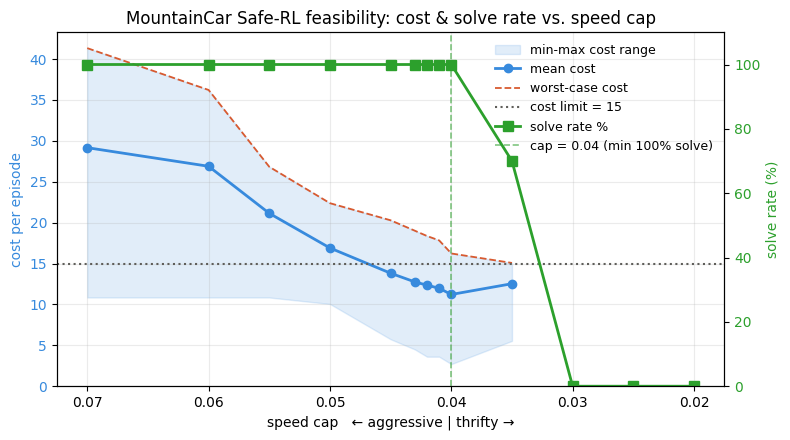

In [25]:
caps_arr  = np.array([x['cap']       for x in rows])
cmean     = np.array([x['cmean']     for x in rows])
cmin      = np.array([x['cmin']      for x in rows])
cmax      = np.array([x['cmax']      for x in rows])
solve_pct = np.array([x['rate'] * 100 for x in rows])

fig, ax1 = plt.subplots(figsize=(8, 4.5))

# --- cost axis (left) ---
ax1.fill_between(caps_arr, cmin, cmax, color='#378ADD', alpha=0.15, label='min-max cost range')
ax1.plot(caps_arr, cmean, '-o', color='#378ADD', lw=2, label='mean cost')
ax1.plot(caps_arr, cmax,  '--', color='#D85A30', lw=1.3, label='worst-case cost')
ax1.axhline(COST_LIMIT, color='#5F5E5A', lw=1.5, ls=':', label=f'cost limit = {COST_LIMIT:.0f}')
ax1.set_ylabel('cost per episode', color='#378ADD')
ax1.tick_params(axis='y', labelcolor='#378ADD')
ax1.set_ylim(0, None)

# --- solve-rate axis (right) ---
ax2 = ax1.twinx()
ax2.plot(caps_arr, solve_pct, '-s', color='#2CA02C', lw=2, ms=7, label='solve rate %')
ax2.axvline(SPEED_THRESH, color='#2CA02C', lw=1.2, ls='--', alpha=0.6,
            label=f'cap = {SPEED_THRESH} (min 100% solve)')
ax2.set_ylabel('solve rate (%)', color='#2CA02C')
ax2.tick_params(axis='y', labelcolor='#2CA02C')
ax2.set_ylim(0, 110)

# --- shared formatting ---
ax1.invert_xaxis()
ax1.set_xlabel('speed cap   ← aggressive | thrifty →')
ax1.set_title('MountainCar Safe-RL feasibility: cost & solve rate vs. speed cap')
ax1.grid(alpha=0.25)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig('cost_vs_speed_cap.png', dpi=130, bbox_inches='tight')
plt.show()

## Conclusion

- **Feasible, but thin.** The thriftiest solver (cap = 0.040) reaches a mean cost
  of ~11 — below the limit of 15. So a safe region does exist.
- **Plain speeding ~29** — almost 2x the limit. To pass, the agent has to be
  deliberately conservative (more steps → lower reward).
- **Not 100% safe across all starts.** Even at the tightest cap, the max column is
  still ~16, and only ~57% of episodes have cost <= 15.

Implication: run Stage 2, but with realistic return expectations (there is a
trade-off), and if cost plateaus around ~16-18 without coming down without breaking
the solve, relax `cost_limit` to ~18-20.